# Simple EDA Notebook

This notebook uses only `numpy`, `pandas`, `matplotlib`, and `seaborn`.

It loads the raw CSV data directly and uses one cell per plot.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [17]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "eda_plots" / "jupyter_simple"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_DIR, OUTPUT_DIR

(WindowsPath('C:/Users/91816/OneDrive/Desktop/Barclays123/AI_CreditScoring/data/raw'),
 WindowsPath('C:/Users/91816/OneDrive/Desktop/Barclays123/AI_CreditScoring/notebooks/eda_plots/jupyter_simple'))

In [18]:
app_train = pd.read_csv(RAW_DIR / "application_train.csv")
app_train.shape

(307511, 122)

In [19]:
app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
eda_df = app_train.copy()
eda_df["DAYS_EMPLOYED_ANOM"] = (eda_df["DAYS_EMPLOYED"] == 365243).astype(int)
eda_df["DAYS_EMPLOYED_CLEAN"] = eda_df["DAYS_EMPLOYED"].replace(365243, np.nan)
income_cap = eda_df["AMT_INCOME_TOTAL"].quantile(0.99)
eda_df["AMT_INCOME_TOTAL_CAPPED"] = eda_df["AMT_INCOME_TOTAL"].clip(upper=income_cap)

income_cap

np.float64(472500.0)

## Plot 1: Target Distribution

C:\Users\91816\AppData\Local\Temp\ipykernel_101340\1054533231.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=eda_df, x="TARGET", palette=["#1D9E75", "#D85A30"])


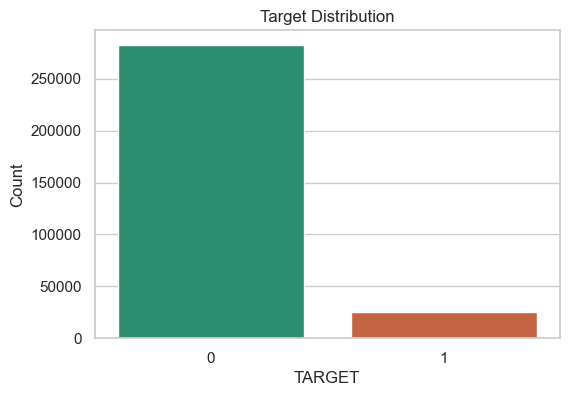

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(data=eda_df, x="TARGET", palette=["#1D9E75", "#D85A30"])
plt.title("Target Distribution")
plt.xlabel("TARGET")
plt.ylabel("Count")
plt.savefig(OUTPUT_DIR / "target_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

## Plot 2: Missing Value Heatmap

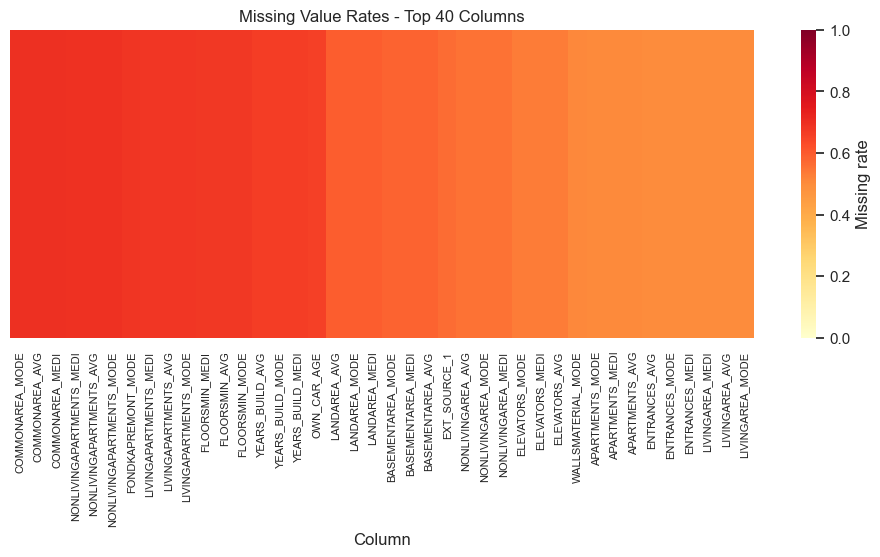

In [22]:
missing_rates = eda_df.isna().mean().sort_values(ascending=False)
missing_top = missing_rates[missing_rates > 0].head(40)

plt.figure(figsize=(12, 4))
sns.heatmap(missing_top.to_frame().T, cmap="YlOrRd", vmin=0, vmax=1, cbar_kws={"label": "Missing rate"})
plt.title("Missing Value Rates - Top 40 Columns")
plt.xlabel("Column")
plt.xticks(rotation=90, fontsize=8)
plt.yticks([])
plt.savefig(OUTPUT_DIR / "missing_value_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

## Plot 3: EXT_SOURCE Correlation Heatmap

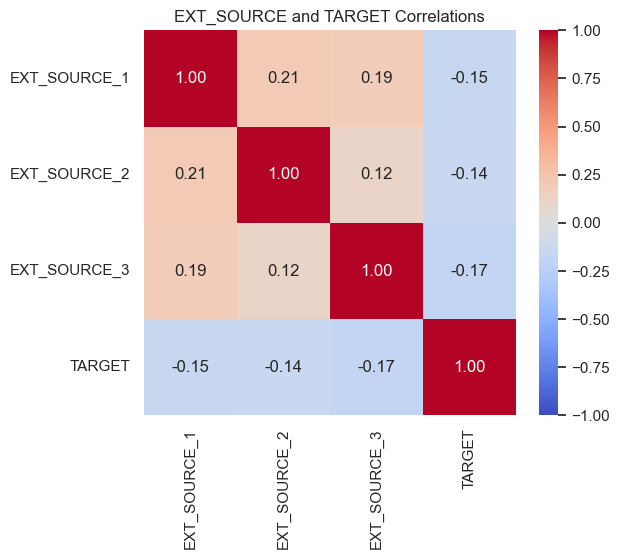

In [23]:
corr_df = eda_df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "TARGET"]].dropna().corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("EXT_SOURCE and TARGET Correlations")
plt.savefig(OUTPUT_DIR / "ext_source_correlation.png", dpi=160, bbox_inches="tight")
plt.show()

## Plot 4: DAYS_EMPLOYED With Sentinel Value

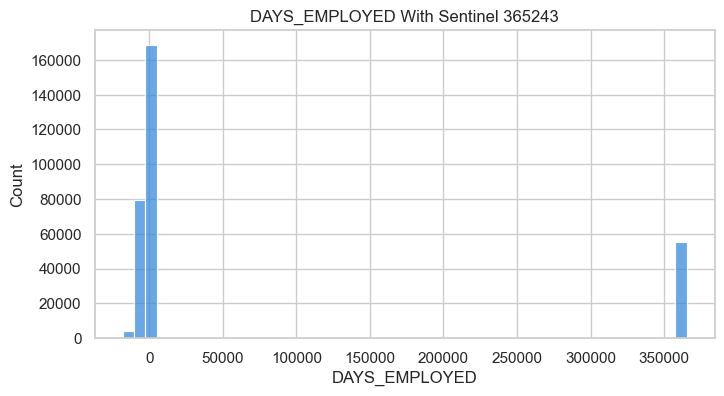

In [24]:
plt.figure(figsize=(8, 4))
sns.histplot(eda_df["DAYS_EMPLOYED"].dropna(), bins=50, color="#378ADD")
plt.title("DAYS_EMPLOYED With Sentinel 365243")
plt.xlabel("DAYS_EMPLOYED")
plt.ylabel("Count")
plt.savefig(OUTPUT_DIR / "days_employed_with_sentinel.png", dpi=160, bbox_inches="tight")
plt.show()

## Plot 5: DAYS_EMPLOYED After Cleaning

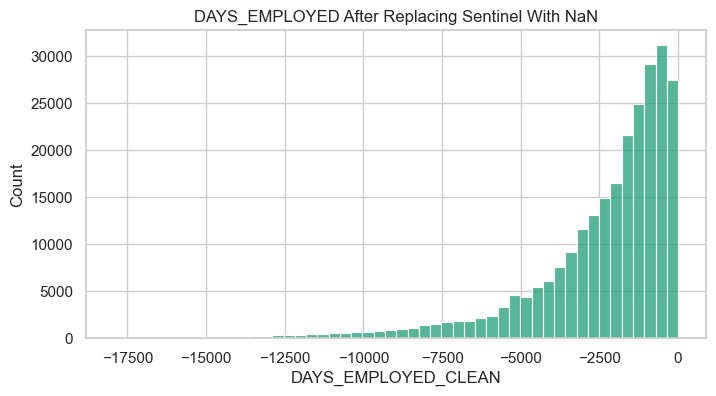

In [25]:
plt.figure(figsize=(8, 4))
sns.histplot(eda_df["DAYS_EMPLOYED_CLEAN"].dropna(), bins=50, color="#1D9E75")
plt.title("DAYS_EMPLOYED After Replacing Sentinel With NaN")
plt.xlabel("DAYS_EMPLOYED_CLEAN")
plt.ylabel("Count")
plt.savefig(OUTPUT_DIR / "days_employed_clean.png", dpi=160, bbox_inches="tight")
plt.show()

## Plot 6: Income Distribution Raw

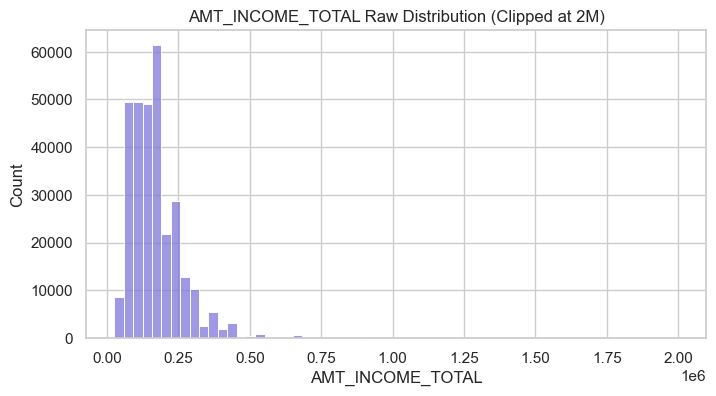

In [26]:
plt.figure(figsize=(8, 4))
sns.histplot(eda_df["AMT_INCOME_TOTAL"].clip(upper=2_000_000).dropna(), bins=60, color="#7F77DD")
plt.title("AMT_INCOME_TOTAL Raw Distribution (Clipped at 2M)")
plt.xlabel("AMT_INCOME_TOTAL")
plt.ylabel("Count")
plt.savefig(OUTPUT_DIR / "income_raw.png", dpi=160, bbox_inches="tight")
plt.show()

## Plot 7: Income Distribution After Capping

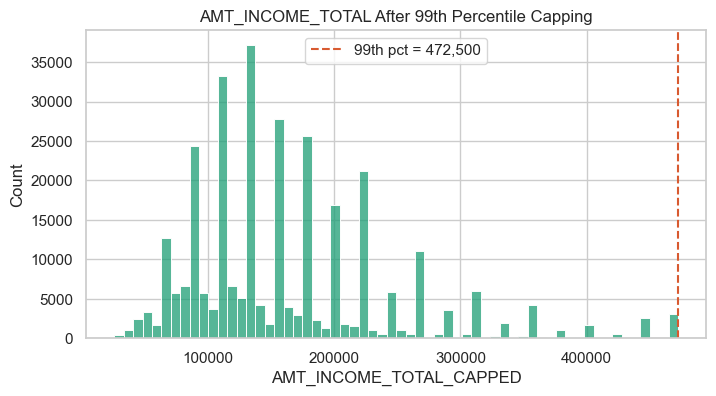

In [27]:
plt.figure(figsize=(8, 4))
sns.histplot(eda_df["AMT_INCOME_TOTAL_CAPPED"].dropna(), bins=60, color="#1D9E75")
plt.axvline(income_cap, color="#D85A30", linestyle="--", label=f"99th pct = {income_cap:,.0f}")
plt.title("AMT_INCOME_TOTAL After 99th Percentile Capping")
plt.xlabel("AMT_INCOME_TOTAL_CAPPED")
plt.ylabel("Count")
plt.legend()
plt.savefig(OUTPUT_DIR / "income_capped.png", dpi=160, bbox_inches="tight")
plt.show()

## Plot 8: EXT_SOURCE_2 Distribution By Target

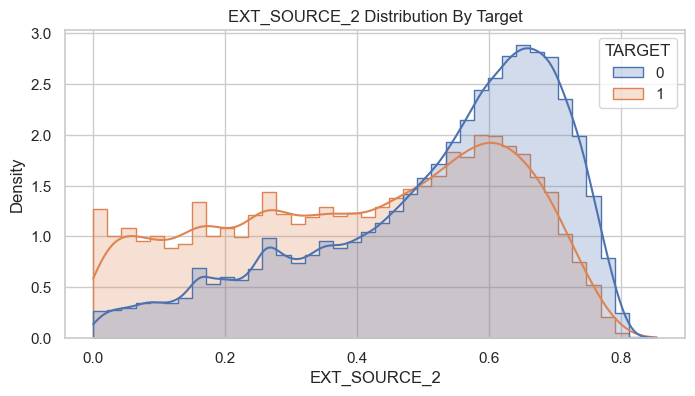

In [28]:
plt.figure(figsize=(8, 4))
sns.histplot(data=eda_df, x="EXT_SOURCE_2", hue="TARGET", bins=40, kde=True, element="step", stat="density", common_norm=False)
plt.title("EXT_SOURCE_2 Distribution By Target")
plt.xlabel("EXT_SOURCE_2")
plt.ylabel("Density")
plt.savefig(OUTPUT_DIR / "ext_source_2_by_target.png", dpi=160, bbox_inches="tight")
plt.show()

## Plot 9: Top 15 Missing Columns Bar Plot

In [ ]:
missing_bar = missing_rates[missing_rates > 0].head(15).rename_axis("column").reset_index(name="missing_rate")

plt.figure(figsize=(12, 5))
sns.barplot(data=missing_bar, x="column", y="missing_rate", color="#D85A30")
plt.title("Top 15 Columns By Missing Rate")
plt.xlabel("")
plt.ylabel("Missing rate")
plt.xticks(rotation=75, fontsize=8)
plt.savefig(OUTPUT_DIR / "missing_rate_bar_top15.png", dpi=160, bbox_inches="tight")
plt.show()

## Generated Plot Files

In [ ]:
sorted(p.name for p in OUTPUT_DIR.glob("*.png"))